Extracting Data using Kaggle API

In [1]:
# installing the kaggle library
!pip install kaggle

In [2]:
# configure the path of kaggle.jeson file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

importing the Dog vs Cat dataset from kaggle

In [3]:
# kaggle api: Download the dogs-vs-cats dataset (without unzipping)
# If you encounter issues, ensure you have accepted the competition rules on the Kaggle website:
# https://www.kaggle.com/competitions/dogs-vs-cats/rules
!kaggle competitions download -c dogs-vs-cats --force

100% 812M/812M [00:06<00:00, 134MB/s]



In [4]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [5]:
# extracting the compressed data

from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:

from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

In [ ]:
import os

# counting the no of files in train folder

path, dirname, filenames = next(os.walk('/content/train'))
print(str(len(filenames)) + " files")

printing the names of images

In [ ]:
file_names = os.listdir('/content/train')
print(file_names)

importing the Dependencies

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

In [ ]:
# displaying dog images
img = mpimg.imread('/content/train/dog.1000.jpg')
imgplot = plt.imshow(img)
plt.show()

In [ ]:
# displaying cat images
img = mpimg.imread('/content/train/cat.4352.jpg')
imgplot = plt.imshow(img)
plt.show()

In [ ]:
file_names = os.listdir('/content/train')

for i in range(5):

  name = file_names[i]
  print(name[0:3])


In [ ]:
file_names = os.listdir('/content/train')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1
  elif name == 'cat':
    cat_count += 1

print("Number of dog count =" ,dog_count)
print("Number of cat count =", cat_count)




Resizing all the images

In [ ]:
# creating a directry for resizing images

os.mkdir('/content/resized_images')

In [15]:
original_folder = '/content/train/'
resized_folder = '/content/resized_images/'

for i in range(2000):

  filename=os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  newImgPath = resized_folder + filename
  img.save(newImgPath)

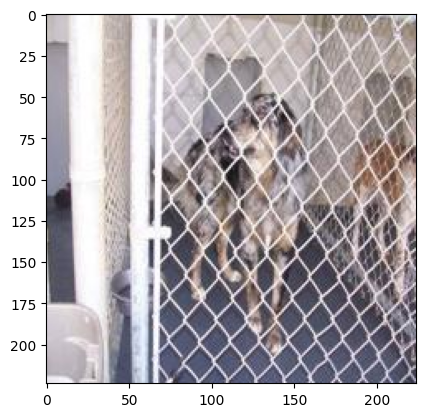

In [16]:
# displaying resized dog images
img = mpimg.imread('/content/resized_images/dog.10072.jpg')
imgplot = plt.imshow(img)
plt.show()

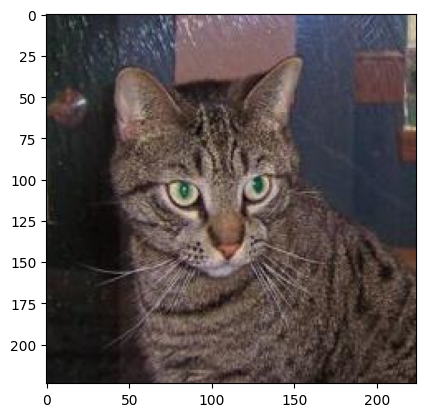

In [17]:
# displaying resized cat images
img = mpimg.imread('/content/resized_images/cat.1.jpg')
imgplot = plt.imshow(img)
plt.show()

Creating labels for resized images of dogs and cats

cat --> 0

dog --> 1

In [18]:
# creating a for loop to assing lables
file_names = os.listdir('/content/resized_images')
labels = []

for i in range(2000):

    file_name = file_names[i]
    label = file_name[0:3]

    if label == 'dog':
      labels.append(1)
    else:
      labels.append(0)

In [19]:
print(filenames[0:5])
print(len(file_names))

['dog.6593.jpg', 'dog.10296.jpg', 'dog.3334.jpg', 'dog.9217.jpg', 'dog.11910.jpg']
2000


In [20]:
print(labels[0:5])
print(len(file_names))

[1, 1, 1, 1, 1]
2000


In [21]:
# counting the images of dogs and cats out of 2000 images
values , count = np.unique(labels, return_counts=True)
print(values)
print(count)

[0 1]
[ 996 1004]


Converting all the resized image to the numpy arrays

In [22]:
import glob

image_directory = '/content/resized_images/'
image_extension = ['png', 'jpg']
files =[]

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([np.asarray(Image.open(file)) for file in files])

In [23]:
print(dog_cat_images)


[[[[ 33  24  15]
   [ 31  22  13]
   [ 38  29  20]
   ...
   [ 26  21  17]
   [ 26  21  17]
   [ 27  22  18]]

  [[ 22  13   4]
   [ 29  20  11]
   [ 46  37  28]
   ...
   [ 25  20  16]
   [ 24  19  15]
   [ 24  19  15]]

  [[ 24  15   6]
   [ 37  28  19]
   [ 57  48  39]
   ...
   [ 23  20  15]
   [ 22  19  14]
   [ 21  18  13]]

  ...

  [[ 32  24  22]
   [ 33  25  23]
   [ 35  27  25]
   ...
   [ 91  77  51]
   [ 96  82  56]
   [103  89  63]]

  [[ 31  23  20]
   [ 30  22  19]
   [ 31  23  20]
   ...
   [ 88  74  48]
   [ 93  79  53]
   [103  89  63]]

  [[ 33  25  22]
   [ 31  23  20]
   [ 31  23  20]
   ...
   [ 82  68  42]
   [ 89  75  49]
   [100  86  60]]]


 [[[200 197 180]
   [193 192 174]
   [175 174 156]
   ...
   [138 135 116]
   [143 136 117]
   [145 139 117]]

  [[191 188 171]
   [194 191 174]
   [180 179 161]
   ...
   [138 135 116]
   [143 136 117]
   [145 139 117]]

  [[192 186 170]
   [204 201 184]
   [197 196 178]
   ...
   [138 135 116]
   [144 137 118]
   [146 140

In [24]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [25]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [26]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 2)

In [27]:
print(X.shape , X_train.shape , X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [28]:
# scalling the data

X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [29]:
print(X_train_scaled)

[[[[0.50196078 0.25098039 0.25490196]
   [0.48627451 0.23529412 0.23921569]
   [0.51372549 0.24313725 0.25490196]
   ...
   [0.20784314 0.11764706 0.18039216]
   [0.21176471 0.11764706 0.17254902]
   [0.21176471 0.11764706 0.17254902]]

  [[0.50196078 0.25098039 0.25490196]
   [0.48235294 0.23137255 0.23529412]
   [0.50980392 0.23921569 0.25098039]
   ...
   [0.21176471 0.12156863 0.18431373]
   [0.21176471 0.11764706 0.17254902]
   [0.21176471 0.11764706 0.17254902]]

  [[0.52156863 0.27058824 0.2745098 ]
   [0.48627451 0.23529412 0.23921569]
   [0.50588235 0.23529412 0.24705882]
   ...
   [0.21176471 0.12156863 0.18431373]
   [0.21568627 0.12156863 0.17647059]
   [0.21568627 0.12156863 0.17647059]]

  ...

  [[0.2745098  0.05490196 0.05098039]
   [0.27843137 0.06666667 0.05882353]
   [0.29803922 0.07843137 0.0745098 ]
   ...
   [0.09411765 0.09803922 0.16862745]
   [0.09803922 0.10196078 0.17254902]
   [0.09803922 0.10196078 0.17254902]]

  [[0.36862745 0.10980392 0.11372549]
   [0.3

**Building the Neural Network**

In [30]:
import tensorflow as tf
import tensorflow_hub as hub

In [31]:
mobilenet_model = 'https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model , input_shape = (224,224,3) , trainable = False)


In [51]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [52]:
model.fit(X_train_scaled , Y_train , epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9463 - loss: 0.1261
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9819 - loss: 0.0464
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9937 - loss: 0.0208
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9975 - loss: 0.0106
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9962 - loss: 0.0122


In [53]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 300ms/step - accuracy: 0.9775 - loss: 0.0720
Test Loss = 0.07204816490411758
Test Accuracy = 0.9775000214576721


**Predictive System**

Path of the image to be predicted: /content/cat.jpeg


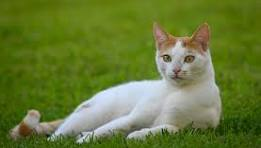

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
The image represents a Cat


In [47]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np # Ensure numpy is imported

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

# Check if image was loaded successfully
if input_image is None:
  print(f"Error: Could not load image from {input_image_path}. Please check the path.")
else:
  cv2_imshow(input_image)

  input_image_resize = cv2.resize(input_image, (224,224))

  input_image_scaled = input_image_resize/255

  image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

  input_prediction = model.predict(image_reshaped)

  input_pred_label = np.argmax(input_prediction)

  if input_pred_label == 0:
    print('The image represents a Cat')

  else:
    print('The image represents a Dog')


Path of the image to be predicted: /content/Dog.jpeg


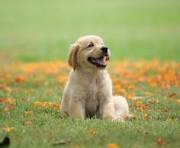

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The image represents a Cat


In [48]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np # Ensure numpy is imported

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

# Check if image was loaded successfully
if input_image is None:
  print(f"Error: Could not load image from {input_image_path}. Please check the path.")
else:
  cv2_imshow(input_image)

  input_image_resize = cv2.resize(input_image, (224,224))

  input_image_scaled = input_image_resize/255

  image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

  input_prediction = model.predict(image_reshaped)

  input_pred_label = np.argmax(input_prediction)

  if input_pred_label == 0:
    print('The image represents a Cat')

  else:
    print('The image represents a Dog')


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step
Classification Report:
              precision    recall  f1-score   support

         Cat       0.98      0.97      0.98       200
         Dog       0.98      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



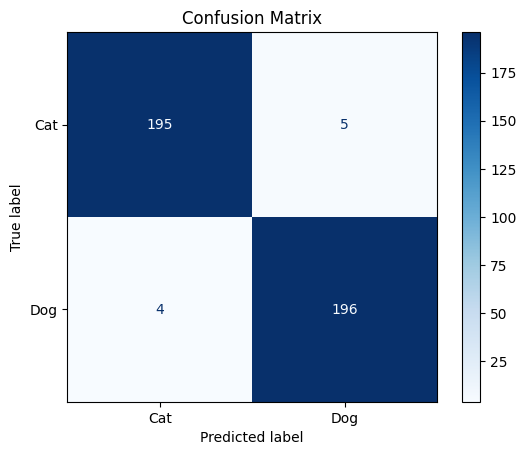

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for argmax

# Get predictions for the test set
Y_pred_raw = model.predict(X_test_scaled)
Y_pred = np.argmax(Y_pred_raw, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

all_unique_labels = np.unique(np.concatenate((Y_test, Y_pred)))

display_labels_map = {0: 'Cat', 1: 'Dog'}
final_display_labels = [display_labels_map.get(label) for label in all_unique_labels]

print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=['Cat', 'Dog'], labels=all_unique_labels))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()